# 04 — Lesion Segmentation

Binary pixel-level segmentation of brain lesions (Bleeding / Ischemia) using a
**U-Net with a pretrained ResNet-50 encoder** (frozen) and a learned decoder.

| Stage | Details |
|---|---|
| Encoder | ResNet-50 ImageNet pretrained, frozen |
| Decoder | Four upsampling blocks with skip connections |
| Loss | 0.5 × BCE + 0.5 × Dice |
| Metrics | Dice coefficient, IoU (Jaccard) |

C:\Users\Beddad\AppData\Roaming\Python\Python313\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


Config OK
  IMG_SIZE=256, BATCH_SIZE=16, SEED=42
  CLASS_TO_IDX: {'Bleeding': 0, 'Ischemia': 1, 'Normal': 2}
Total samples : 6,650
Train         : 4,987
Val           : 998
Test (internal): 665

Train: Bleeding: 820, Ischemia: 847, Normal: 3320
Val: Bleeding: 164, Ischemia: 170, Normal: 664
Test: Bleeding: 109, Ischemia: 113, Normal: 443
External Test samples : 200
  With masks          : 200
  Without masks       : 0
  With clf labels     : 200 (Stroke: 70, Normal: 130)
Augmentation pipelines:
  Train: ['Resize', 'HorizontalFlip', 'VerticalFlip', 'Rotate', 'RandomBrightnessContrast', 'GaussNoise', 'ElasticTransform', 'Normalize', 'ToTensorV2']
  Val  : ['Resize', 'Normalize', 'ToTensorV2']
Sample — image: torch.Size([1, 256, 256]), dtype: torch.float32, range: [-0.69, 1.00]
         label: 2 (Normal)
Seg sample — image: torch.Size([1, 256, 256]), mask: torch.Size([256, 256])
             mask unique: [0]
Seg train: 4987, val: 998, internal test: 665, external test: 200
Class weights f

C:\Users\Beddad\AppData\Local\Temp\ipykernel_34056\4222860289.py:28: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.3),
C:\Users\Beddad\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Classification batch — images: torch.Size([16, 1, 256, 256]), labels: torch.Size([16])
  Image range: [-1.000, 1.000]
  Labels: [1, 2, 1, 2, 0, 0, 2, 2, 2, 2, 1, 2, 2, 2, 0, 2]


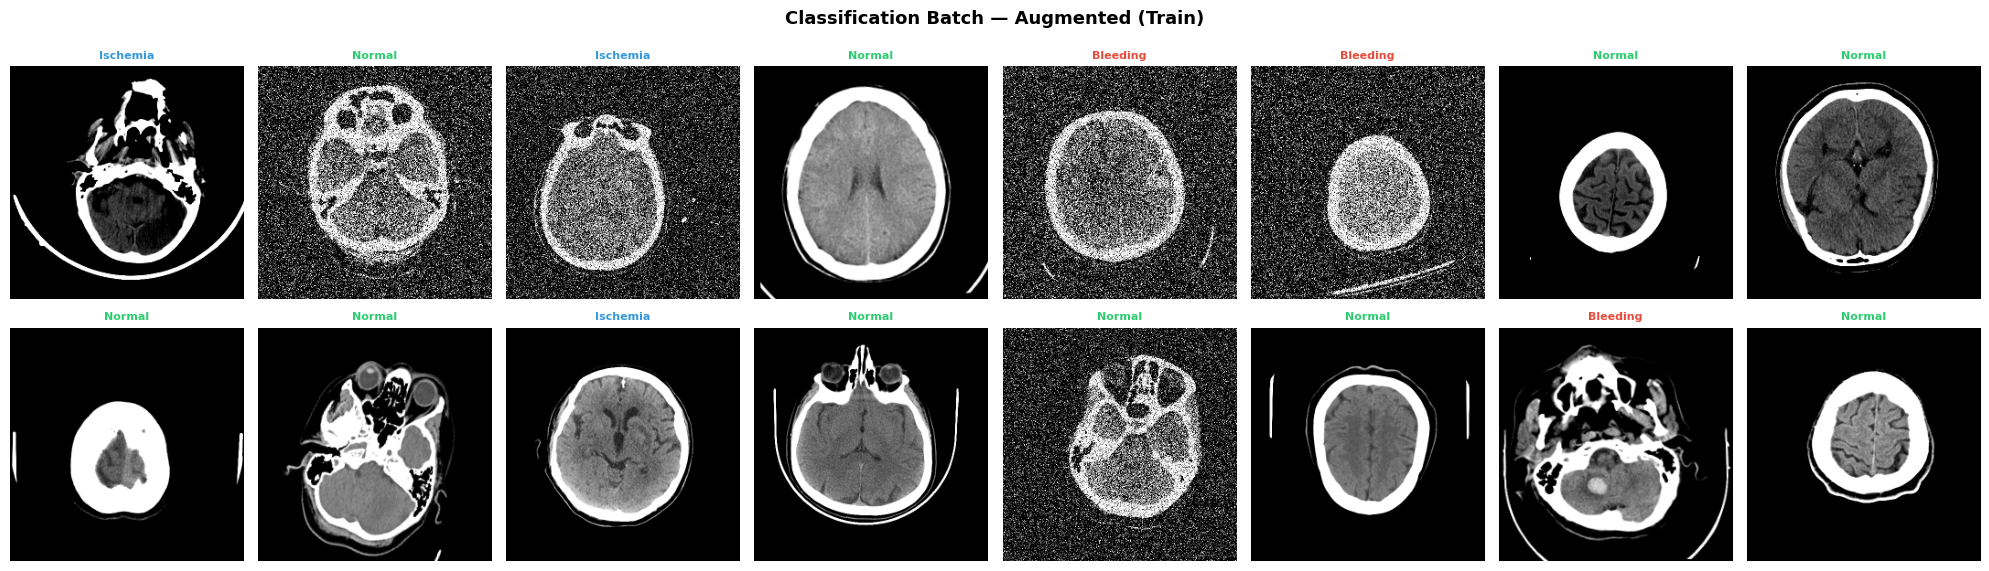

Segmentation batch — images: torch.Size([16, 1, 256, 256]), masks: torch.Size([16, 256, 256])
  Mask unique values: [0, 1]
  Positive pixels (lesion) in batch: 259739 / 1048576
  Samples with lesion in this batch: 4/16


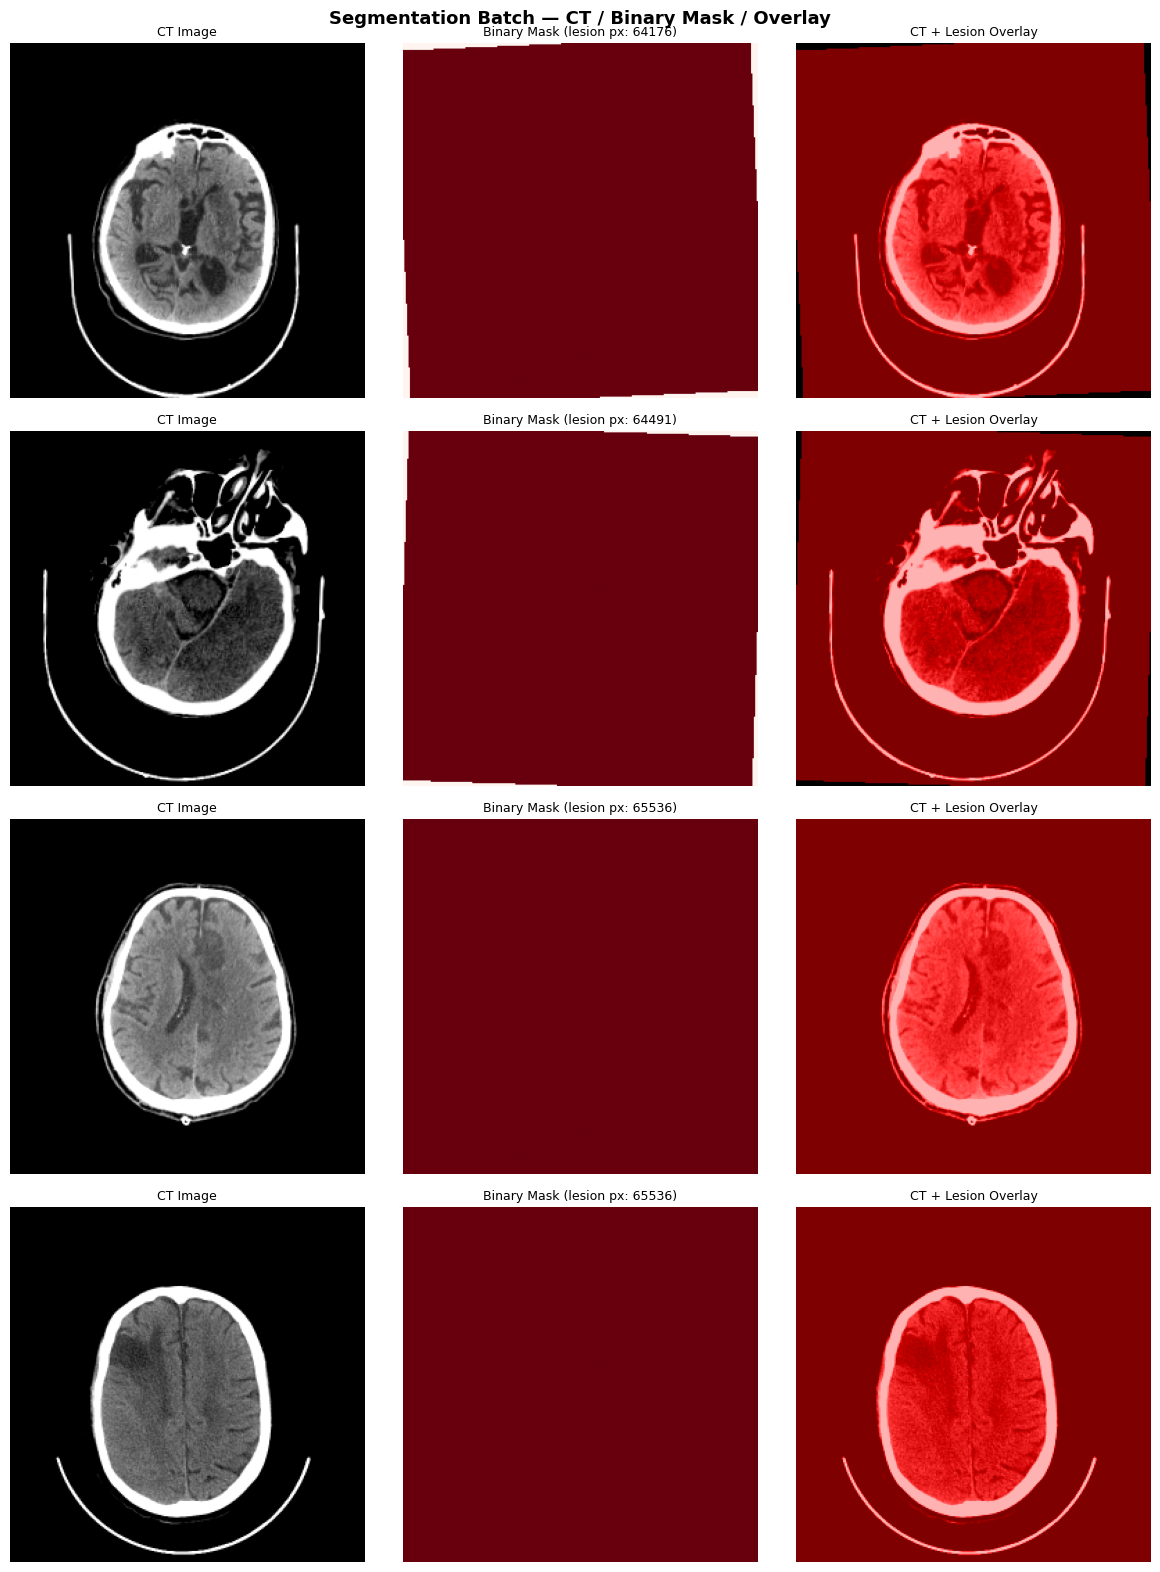

Lesion coverage in segmentation training set (sample of 200)...


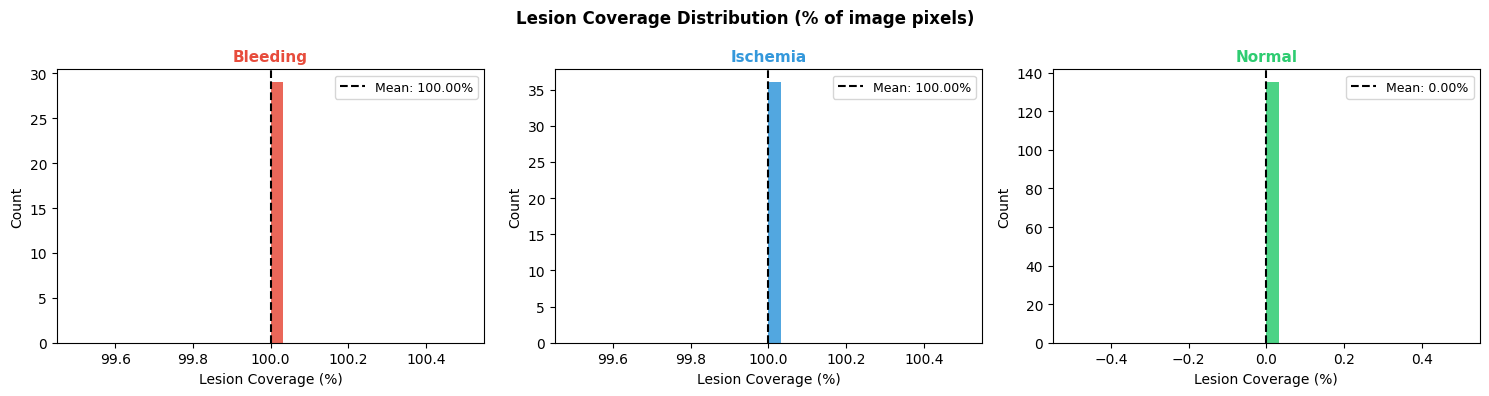

Bleeding    : mean=100.00%, max=100.00%, zero_masks=0/29
Ischemia    : mean=100.00%, max=100.00%, zero_masks=0/36
Normal      : mean=0.00%, max=0.00%, zero_masks=135/135
Ready for training!

Classification:
  clf_train_loader : 312 batches x 16
  clf_val_loader   : 63 batches
  clf_test_loader  : 42 batches
  ext_clf_loader   : 13 batches (External_Test binary)
  class_weights    : [2.027235746383667, 1.9626131057739258, 0.5007027983665466]

Segmentation:
  seg_train_loader : 312 batches x 16
  seg_val_loader   : 63 batches
  seg_test_loader  : 42 batches
  seg_ext_loader   : 13 batches (External_Test)


In [1]:
%run 02_dataloaders.ipynb

In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import models
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)
import seaborn as sns

In [3]:
# ── Config ────────────────────────────────────────────────────────────────────
NUM_EPOCHS = 15
LR         = 1e-3          # higher LR is fine — only decoder is trained
LR_MIN     = 1e-5
THRESHOLD  = 0.5           # binarisation threshold for predictions
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
best_ckpt  = Path('../checkpoints/unet_resnet50_best.pth')
best_ckpt.parent.mkdir(parents=True, exist_ok=True)

print(f'Device : {DEVICE}')
print(f'Epochs : {NUM_EPOCHS}')
print(f'LR     : {LR}')

Device : cpu
Epochs : 15
LR     : 0.001


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

# ── Building blocks ───────────────────────────────────────────────────────────
class DoubleConv(nn.Module):
    """Two 3×3 conv → BN → ReLU blocks."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class UNetResNet50(nn.Module):
    """
    U-Net with a pretrained ResNet-50 encoder.
    Input : (B, 1, H, W)   — grayscale CT
    Output: (B, 1, H, W)   — raw logits for binary mask
    """
    def __init__(self, num_classes=1, pretrained=True, freeze_encoder=True):
        super().__init__()
        weights  = models.ResNet50_Weights.DEFAULT if pretrained else None
        backbone = models.resnet50(weights=weights)

        # Patch first conv: RGB (3-ch) → grayscale (1-ch)
        old_conv = backbone.conv1
        new_conv = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            new_conv.weight = nn.Parameter(old_conv.weight.mean(dim=1, keepdim=True))
        backbone.conv1 = new_conv

        # Encoder stages — output channels & spatial strides:
        #   e0 : 64   ch, H/2
        #   e1 : 256  ch, H/4
        #   e2 : 512  ch, H/8
        #   e3 : 1024 ch, H/16
        #   e4 : 2048 ch, H/32  (bottleneck)
        self.e0 = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu)
        self.e1 = nn.Sequential(backbone.maxpool, backbone.layer1)
        self.e2 = backbone.layer2
        self.e3 = backbone.layer3
        self.e4 = backbone.layer4

        if freeze_encoder:
            for stage in [self.e0, self.e1, self.e2, self.e3, self.e4]:
                for p in stage.parameters():
                    p.requires_grad = False

        # Decoder — channel arithmetic (concat of upsampled + skip):
        #   d4 : (2048+1024) → 512
        #   d3 : (512 + 512) → 256
        #   d2 : (256 + 256) → 128
        #   d1 : (128 +  64) →  64
        #   d0 : 64          →  32  (final H)
        self.d4 = DoubleConv(2048 + 1024, 512)
        self.d3 = DoubleConv(512  + 512,  256)
        self.d2 = DoubleConv(256  + 256,  128)
        self.d1 = DoubleConv(128  + 64,    64)
        self.d0 = DoubleConv(64,            32)
        self.head = nn.Conv2d(32, num_classes, kernel_size=1)

    @staticmethod
    def _cat_up(x, skip):
        """Bilinear upsample x to skip's spatial size, then concat."""
        x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        return torch.cat([x, skip], dim=1)

    def forward(self, x):
        s0 = self.e0(x)   # 64,   H/2
        s1 = self.e1(s0)  # 256,  H/4
        s2 = self.e2(s1)  # 512,  H/8
        s3 = self.e3(s2)  # 1024, H/16
        b  = self.e4(s3)  # 2048, H/32

        x = self.d4(self._cat_up(b,  s3))  # 512,  H/16
        x = self.d3(self._cat_up(x,  s2))  # 256,  H/8
        x = self.d2(self._cat_up(x,  s1))  # 128,  H/4
        x = self.d1(self._cat_up(x,  s0))  # 64,   H/2
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        x = self.d0(x)                      # 32,   H
        return self.head(x)                 # 1,    H


model = UNetResNet50(num_classes=1, pretrained=True, freeze_encoder=True).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model     : U-Net / ResNet-50 encoder (grayscale, encoder frozen)')
print(f'Params    : {total:,} total | {trainable:,} trainable | {total-trainable:,} frozen')

Model     : U-Net / ResNet-50 encoder (grayscale, encoder frozen)
Params    : 43,882,337 total | 20,380,577 trainable | 23,501,760 frozen


In [5]:
# ── Loss & metrics ────────────────────────────────────────────────────────────
def dice_loss(logits, targets, eps=1e-6):
    """Soft Dice loss (works on raw logits via sigmoid)."""
    probs = torch.sigmoid(logits)
    # flatten spatial dims
    probs   = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1).float()
    intersection = (probs * targets).sum(dim=1)
    union        = probs.sum(dim=1) + targets.sum(dim=1)
    dice         = (2. * intersection + eps) / (union + eps)
    return 1. - dice.mean()


def combined_loss(logits, targets):
    """0.5 × BCE + 0.5 × Dice."""
    bce  = F.binary_cross_entropy_with_logits(logits, targets.float())
    dice = dice_loss(logits, targets)
    return 0.5 * bce + 0.5 * dice


@torch.no_grad()
def dice_score(logits, targets, threshold=THRESHOLD, eps=1e-6):
    """Hard Dice coefficient (per-batch mean)."""
    preds   = (torch.sigmoid(logits) > threshold).float()
    preds   = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1).float()
    inter   = (preds * targets).sum(dim=1)
    union   = preds.sum(dim=1) + targets.sum(dim=1)
    return ((2. * inter + eps) / (union + eps)).mean().item()


@torch.no_grad()
def iou_score(logits, targets, threshold=THRESHOLD, eps=1e-6):
    """Intersection-over-Union / Jaccard (per-batch mean)."""
    preds   = (torch.sigmoid(logits) > threshold).float()
    preds   = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1).float()
    inter   = (preds * targets).sum(dim=1)
    union   = preds.sum(dim=1) + targets.sum(dim=1) - inter
    return ((inter + eps) / (union + eps)).mean().item()


criterion = combined_loss
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4
)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=LR_MIN)

print('Loss      : 0.5 × BCE + 0.5 × Dice')
print(f'Optimizer : AdamW (lr={LR}, wd=1e-4) — decoder only')
print(f'Scheduler : CosineAnnealingLR (T_max={NUM_EPOCHS}, eta_min={LR_MIN})')

Loss      : 0.5 × BCE + 0.5 × Dice
Optimizer : AdamW (lr=0.001, wd=1e-4) — decoder only
Scheduler : CosineAnnealingLR (T_max=15, eta_min=1e-05)


In [6]:
# ── Training & evaluation functions ───────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, total_dice, n = 0., 0., 0
    for imgs, masks in loader:
        imgs  = imgs.to(device)
        masks = masks.unsqueeze(1).to(device)   # (B,1,H,W)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        bs          = imgs.size(0)
        total_loss += loss.item() * bs
        total_dice += dice_score(logits, masks) * bs
        n          += bs
    return total_loss / n, total_dice / n


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss, total_dice, total_iou, n = 0., 0., 0., 0
    for imgs, masks in loader:
        imgs  = imgs.to(device)
        masks = masks.unsqueeze(1).to(device)
        logits = model(imgs)
        loss   = criterion(logits, masks)
        bs          = imgs.size(0)
        total_loss += loss.item() * bs
        total_dice += dice_score(logits, masks) * bs
        total_iou  += iou_score(logits, masks) * bs
        n          += bs
    return total_loss / n, total_dice / n, total_iou / n

print('Training functions defined.')

Training functions defined.


In [7]:
# ── Training loop ─────────────────────────────────────────────────────────────
history     = defaultdict(list)
best_dice   = 0.

print(f'Training for {NUM_EPOCHS} epochs on {DEVICE}...')
print(f'{"Epoch":<7} {"Train Loss":<13} {"Train Dice":<13} '
      f'{"Val Loss":<12} {"Val Dice":<11} {"Val IoU":<10} LR')
print('-' * 84)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_dice               = train_one_epoch(model, seg_train_loader, optimizer, DEVICE)
    val_loss, val_dice, val_iou    = evaluate(model, seg_val_loader, DEVICE)
    cur_lr = scheduler.get_last_lr()[0]
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_dice'].append(tr_dice)
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['val_iou'].append(val_iou)
    history['lr'].append(cur_lr)

    flag = ''
    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), best_ckpt)
        flag = ' ← best'

    print(f'{epoch:<7} {tr_loss:<13.4f} {tr_dice:<13.4f} '
          f'{val_loss:<12.4f} {val_dice:<11.4f} {val_iou:<10.4f} '
          f'{cur_lr:.2e}{flag}')

print(f'\nTraining complete. Best Val Dice: {best_dice:.4f}')
print(f'Best checkpoint: {best_ckpt}')

Training for 15 epochs on cpu...
Epoch   Train Loss    Train Dice    Val Loss     Val Dice    Val IoU    LR
------------------------------------------------------------------------------------


C:\Users\Beddad\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


KeyboardInterrupt: 

In [ ]:
# ── Training curves ───────────────────────────────────────────────────────────
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'],   label='Val')
axes[0].set_title('Loss (BCE + Dice)')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(epochs, history['train_dice'], label='Train')
axes[1].plot(epochs, history['val_dice'],   label='Val')
axes[1].set_title('Dice Coefficient')
axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(epochs, history['val_iou'], color='tab:green')
axes[2].set_title('Val IoU (Jaccard)')
axes[2].set_xlabel('Epoch')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ── Internal test set evaluation ──────────────────────────────────────────────
model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))

test_loss, test_dice, test_iou = evaluate(model, seg_test_loader, DEVICE)

print('=== Internal Test Set ===')
print(f'Loss      : {test_loss:.4f}')
print(f'Dice      : {test_dice:.4f}')
print(f'IoU       : {test_iou:.4f}')

In [ ]:
# ── Visualise predictions on internal test set ────────────────────────────────
model.eval()

# Collect one batch
imgs_batch, masks_batch = next(iter(seg_test_loader))
with torch.no_grad():
    logits_batch = model(imgs_batch.to(DEVICE)).cpu()
pred_batch = (torch.sigmoid(logits_batch) > THRESHOLD).squeeze(1).numpy()
imgs_np    = imgs_batch.squeeze(1).numpy()
masks_np   = masks_batch.numpy()

# Pick 4 samples that have a non-empty ground-truth mask
has_lesion = [i for i in range(len(masks_np)) if masks_np[i].sum() > 0]
show_idx   = has_lesion[:4] if len(has_lesion) >= 4 else list(range(min(4, len(masks_np))))

fig, axes = plt.subplots(len(show_idx), 3, figsize=(10, 3 * len(show_idx)))
if len(show_idx) == 1:
    axes = axes[np.newaxis, :]

for row, i in enumerate(show_idx):
    img  = imgs_np[i]
    # un-normalise for display
    img_disp = (img * 0.5 + 0.5).clip(0, 1)
    gt   = masks_np[i]
    pred = pred_batch[i]

    dice_i = (2 * (pred * gt).sum() + 1e-6) / (pred.sum() + gt.sum() + 1e-6)

    axes[row, 0].imshow(img_disp, cmap='gray')
    axes[row, 0].set_title('CT Image')

    axes[row, 1].imshow(img_disp, cmap='gray')
    axes[row, 1].imshow(gt,   cmap='Reds',  alpha=0.4)
    axes[row, 1].set_title('Ground Truth')

    axes[row, 2].imshow(img_disp, cmap='gray')
    axes[row, 2].imshow(pred, cmap='Blues', alpha=0.4)
    axes[row, 2].set_title(f'Prediction  (Dice={dice_i:.3f})')

    for ax in axes[row]:
        ax.axis('off')

plt.suptitle('U-Net Predictions — Internal Test Set', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# ── External test set evaluation ──────────────────────────────────────────────
ext_loss, ext_dice, ext_iou = evaluate(model, seg_ext_loader, DEVICE)

print('=== External Test Set ===')
print(f'Loss      : {ext_loss:.4f}')
print(f'Dice      : {ext_dice:.4f}')
print(f'IoU       : {ext_iou:.4f}')

In [ ]:
# ── Visualise predictions on external test set ────────────────────────────────
model.eval()

imgs_ext, masks_ext = next(iter(seg_ext_loader))
with torch.no_grad():
    logits_ext = model(imgs_ext.to(DEVICE)).cpu()
pred_ext  = (torch.sigmoid(logits_ext) > THRESHOLD).squeeze(1).numpy()
imgs_ext_np  = imgs_ext.squeeze(1).numpy()
masks_ext_np = masks_ext.numpy()

has_lesion_ext = [i for i in range(len(masks_ext_np)) if masks_ext_np[i].sum() > 0]
show_ext = has_lesion_ext[:4] if len(has_lesion_ext) >= 4 else list(range(min(4, len(masks_ext_np))))

fig, axes = plt.subplots(len(show_ext), 3, figsize=(10, 3 * len(show_ext)))
if len(show_ext) == 1:
    axes = axes[np.newaxis, :]

for row, i in enumerate(show_ext):
    img      = imgs_ext_np[i]
    img_disp = (img * 0.5 + 0.5).clip(0, 1)
    gt       = masks_ext_np[i]
    pred     = pred_ext[i]
    dice_i   = (2 * (pred * gt).sum() + 1e-6) / (pred.sum() + gt.sum() + 1e-6)

    axes[row, 0].imshow(img_disp, cmap='gray')
    axes[row, 0].set_title('CT Image')
    axes[row, 1].imshow(img_disp, cmap='gray')
    axes[row, 1].imshow(gt,   cmap='Reds',  alpha=0.4)
    axes[row, 1].set_title('Ground Truth')
    axes[row, 2].imshow(img_disp, cmap='gray')
    axes[row, 2].imshow(pred, cmap='Blues', alpha=0.4)
    axes[row, 2].set_title(f'Prediction  (Dice={dice_i:.3f})')

    for ax in axes[row]:
        ax.axis('off')

plt.suptitle('U-Net Predictions — External Test Set', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# ── Summary ───────────────────────────────────────────────────────────────────
print('=' * 55)
print('SEGMENTATION SUMMARY')
print('=' * 55)
print(f'Model          : U-Net / ResNet-50 encoder (1-ch, frozen)')
print(f'Best Val Dice  : {best_dice:.4f}')
print()
print('Internal Test:')
print(f'  Dice         : {test_dice:.4f}')
print(f'  IoU          : {test_iou:.4f}')
print()
print('External Test:')
print(f'  Dice         : {ext_dice:.4f}')
print(f'  IoU          : {ext_iou:.4f}')
print()
print(f'Checkpoint     : {best_ckpt}')